# KNN 與邏輯迴歸 (KNN & Logistic Regression)

學習目標：
- 了解 KNN 的直覺：找最近的鄰居
- 學會邏輯迴歸做二元分類
- 比較兩種方法的優缺點

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import make_classification

## 1. KNN 直覺

K-Nearest Neighbors：看「最近的K個鄰居」屬於哪類。

運動員例子：
要判斷一位新選手是「菁英」還是「一般」，
就找體能指標最接近的K位已知選手，
多數是哪類就判為哪類。

K 太小 → 容易過擬合
K 太大 → 邊界太模糊

In [2]:
# 建立模擬資料（運動員分類）
X, y = make_classification(n_samples=500, n_features=2,
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# 測試不同 K 值
k_values = [1, 3, 5, 10, 20]
print(f'{"K值":<6} {"Accuracy":>10}')
print('-' * 18)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    print(f'{k:<6} {acc:>10.3f}')

K值       Accuracy
------------------
1           0.960
3           0.960
5           0.960
10          0.960
20          0.940


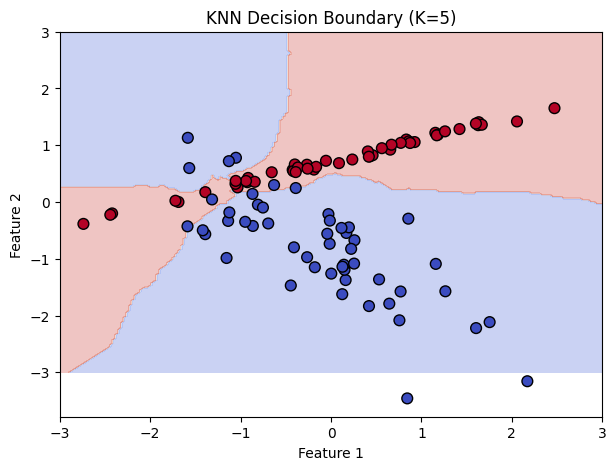

In [3]:
# 視覺化 KNN 決策邊界（K=5）
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

xx, yy = np.meshgrid(np.linspace(-3, 3, 200),
                     np.linspace(-3, 3, 200))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, cmap='coolwarm', edgecolors='k', s=60)
plt.title('KNN Decision Boundary (K=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 2. 邏輯迴歸

名字叫「迴歸」但其實是分類！
輸出的是「屬於某類的機率」（0~1之間），
超過0.5就判為1類。

優點：快速、可解釋性強（係數代表每個特徵的重要性）
缺點：只能處理線性可分的問題

In [4]:
# 邏輯迴歸
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('邏輯迴歸結果：')
print(classification_report(y_test, y_pred_lr))
print(f'特徵1係數：{lr.coef_[0][0]:.3f}')
print(f'特徵2係數：{lr.coef_[0][1]:.3f}')

邏輯迴歸結果：
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        51
           1       0.88      0.88      0.88        49

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

特徵1係數：0.427
特徵2係數：3.122


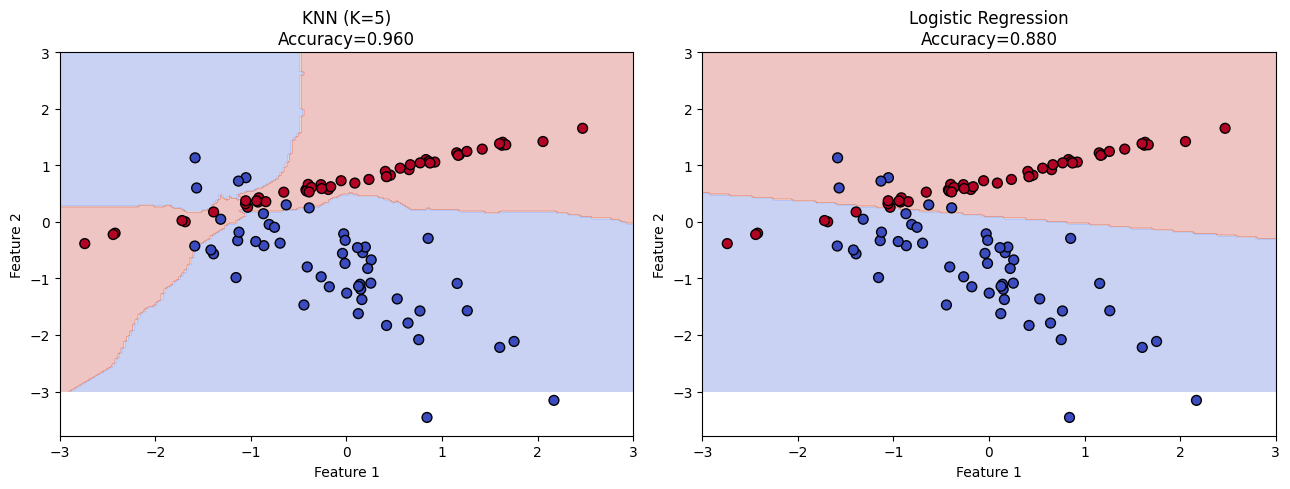

In [5]:
# 並排比較 KNN vs 邏輯迴歸決策邊界
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title in zip(
        axes,
        [knn, lr],
        ['KNN (K=5)', 'Logistic Regression']):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_test[:, 0], X_test[:, 1],
               c=y_test, cmap='coolwarm',
               edgecolors='k', s=50)
    acc = accuracy_score(y_test, model.predict(X_test))
    ax.set_title(f'{title}\nAccuracy={acc:.3f}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 3. 我的學習筆記

1. 這個主題在做什麼：
   用兩種不同的分類方法預測類別，
   並比較各自的決策邊界形狀和準確率。

2. KNN vs 邏輯迴歸：
   - KNN：不需要訓練，直接比較距離，邊界彈性
   - 邏輯迴歸：需要訓練，速度快，邊界是直線

3. 我覺得最難理解的地方：
   KNN概念

4. 這個跟我研究的連結：
   判斷運動員是否為菁英選手是典型的二元分類問題，
   邏輯迴歸的係數可以告訴我們哪個體能指標最關鍵，
   這跟 AHP 找關鍵指標的思路很像。